# Feature Engineering V3 — EDA
Exploratory analysis of all `_v2` tables produced by `FeatureEngineering_v3.ipynb`.

**Tables covered:**
- `activity_base_v2`, `activity_labeled_v2`, `activity_dictionary_v2`, `activity_effort_mapping_ai_v2`
- `contact_one_row_v2`, `developer_universe_v2`
- `dev_recency_features_v2`, `dev_features_lifetime_v2`
- `dev_features_0_30d_v2`, `dev_features_30_90d_v2`, `dev_features_90_180d_v2`
- `dev_weekly_features_v2`, `dev_meaningful_week_v2`
- `dev_effort_level_v2`, `dev_persona_v2`, `dev_contact_persona_v2`
- `dev_journey_state_v2`, `dev_dormancy_status_v2`, `dev_activation_v2`
- `dev_profile_final_v4`

## 1. Setup

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 200)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

DB_PATH = "developer_project.duckdb"
con = duckdb.connect(DB_PATH, read_only=True)
print("Connected:", DB_PATH)

Connected: developer_project.duckdb


## 2. Table Inventory

In [2]:
all_tables = con.execute("SHOW TABLES").fetchdf()
v2_tables = all_tables[all_tables['name'].str.endswith('_v2') | all_tables['name'].str.endswith('_v4')].reset_index(drop=True)

row_counts = []
for t in v2_tables['name']:
    n = con.execute(f"SELECT COUNT(*) FROM {t}").fetchone()[0]
    row_counts.append(n)

v2_tables['row_count'] = row_counts
display(v2_tables)

,name,row_count
0,activity_base_v2,69347501
1,activity_dictionary_v2,19
2,activity_effort_mapping_ai_v2,39
3,activity_labeled_v2,69347501
4,activity_ontology_v2,69347501
5,contact_one_row_v2,9381490
6,dev_activation_v2,9381508
7,dev_contact_persona_v2,9381490
8,dev_dormancy_status_v2,9381508
9,dev_effort_level_v2,9381508


## 3. Activity Data (`activity_labeled_v2`)

In [3]:
display(con.execute("DESCRIBE activity_labeled_v2").fetchdf())

,column_name,column_type,null,key,default,extra
0,developer_id,VARCHAR,YES,None,None,None
1,activity_date,DATE,YES,None,None,None
2,activity,VARCHAR,YES,None,None,None
3,activity_name,VARCHAR,YES,None,None,None
4,activity_type,VARCHAR,YES,None,None,None
5,activity_role,VARCHAR,YES,None,None,None
6,activity_attendance,VARCHAR,YES,None,None,None
7,activity_score,DOUBLE,YES,None,None,None
8,filepath,VARCHAR,YES,None,None,None
9,lead_source,VARCHAR,YES,None,None,None


In [4]:
cols = [r[0] for r in con.execute("DESCRIBE activity_labeled_v2").fetchall()]
total = con.execute("SELECT COUNT(*) FROM activity_labeled_v2").fetchone()[0]
null_rates = {}
for col in cols:
    n_null = con.execute(f"SELECT COUNT(*) FROM activity_labeled_v2 WHERE {col} IS NULL").fetchone()[0]
    null_rates[col] = round(100 * n_null / total, 2)

null_df = pd.DataFrame.from_dict(null_rates, orient='index', columns=['null_pct']).sort_values('null_pct', ascending=False)
display(null_df[null_df['null_pct'] > 0])

,null_pct
nvidia_campaign_id,98.9900
filepath,22.1600
ai_effort_match_source,13.4500
ai_activity_score_guideline,13.4500
ai_confidence_weight,13.4500
ai_confidence,13.4500
ai_weighted_effort_rank,13.4500
ai_effort_rank,13.4500
ai_effort_level,13.4500


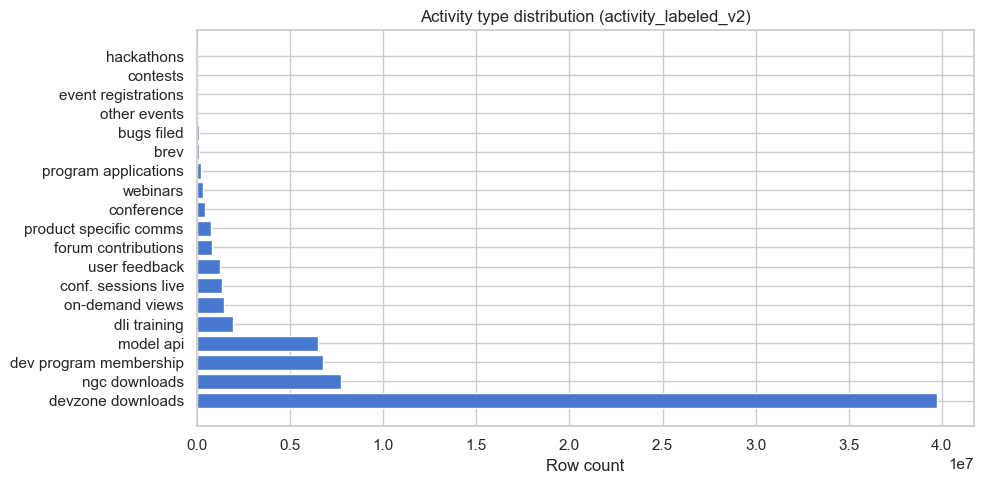

,activity,n
0,devzone downloads,39742594
1,ngc downloads,7720077
2,dev program membership,6767607
3,model api,6466203
4,dli training,1934108
5,on-demand views,1440586
6,conf. sessions live,1312509
7,user feedback,1238576
8,forum contributions,784056
9,product specific comms,742452


In [5]:
act_dist = con.execute("""
    SELECT activity, COUNT(*) AS n
    FROM activity_labeled_v2
    GROUP BY activity
    ORDER BY n DESC
""").fetchdf()

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(act_dist['activity'], act_dist['n'])
ax.set_xlabel('Row count')
ax.set_title('Activity type distribution (activity_labeled_v2)')
plt.tight_layout()
plt.show()
display(act_dist)

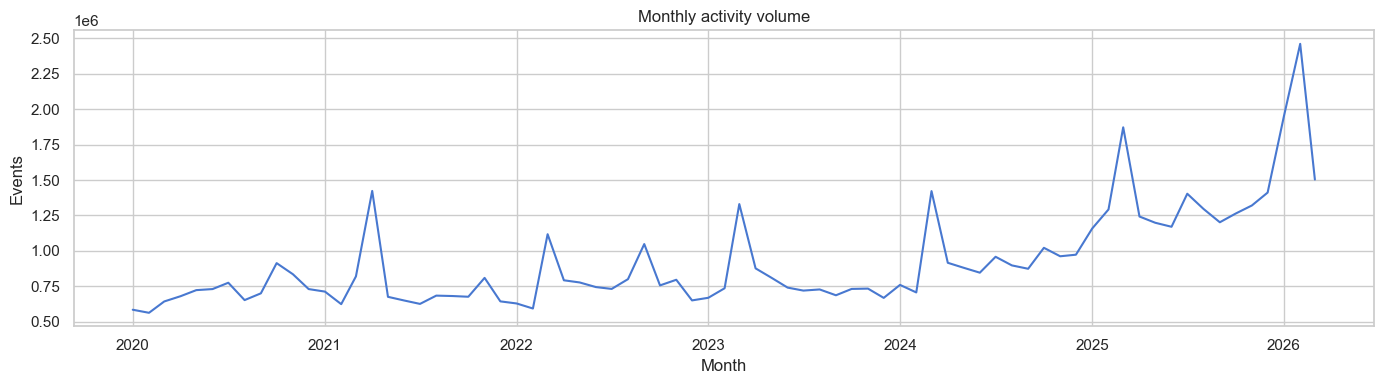

In [6]:
timeline = con.execute("""
    SELECT DATE_TRUNC('month', activity_date) AS month, COUNT(*) AS n
    FROM activity_labeled_v2
    WHERE activity_date IS NOT NULL
    GROUP BY 1 ORDER BY 1
""").fetchdf()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(timeline['month'], timeline['n'])
ax.set_title('Monthly activity volume')
ax.set_xlabel('Month')
ax.set_ylabel('Events')
plt.tight_layout()
plt.show()

In [7]:
jl = con.execute("""
    SELECT journey_signal, COUNT(*) AS n
    FROM activity_labeled_v2
    GROUP BY journey_signal ORDER BY n DESC
""").fetchdf()
display(jl)

,journey_signal,n
0,Build,36397916
1,Discover,16088697
2,Evaluate,10579269
3,Learn,4985463
4,Champion,1296156


## 4. Effort Mapping (`activity_effort_mapping_ai_v2`)

In [9]:
display(con.execute("DESCRIBE activity_effort_mapping_ai_v2").fetchdf())

effort = con.execute("""
    SELECT ai_effort_level, COUNT(*) AS n
    FROM activity_effort_mapping_ai_v2
    GROUP BY ai_effort_level ORDER BY n DESC
""").fetchdf()
display(effort)

,column_name,column_type,null,key,default,extra
0,mapping_object_norm,VARCHAR,YES,None,None,None
1,mapping_field_norm,VARCHAR,YES,None,None,None
2,mapping_value_norm,VARCHAR,YES,None,None,None
3,ai_effort_level,VARCHAR,YES,None,None,None
4,ai_effort_rank,DOUBLE,YES,None,None,None
5,ai_weighted_effort_rank,DOUBLE,YES,None,None,None
6,ai_confidence,VARCHAR,YES,None,None,None
7,ai_confidence_weight,DOUBLE,YES,None,None,None
8,ai_activity_score_guideline,BIGINT,YES,None,None,None
9,ai_effort_notes,VARCHAR,YES,None,None,None


,ai_effort_level,n
0,low,14
1,moderate,13
2,high,8
3,very high,2
4,,1
5,passive,1


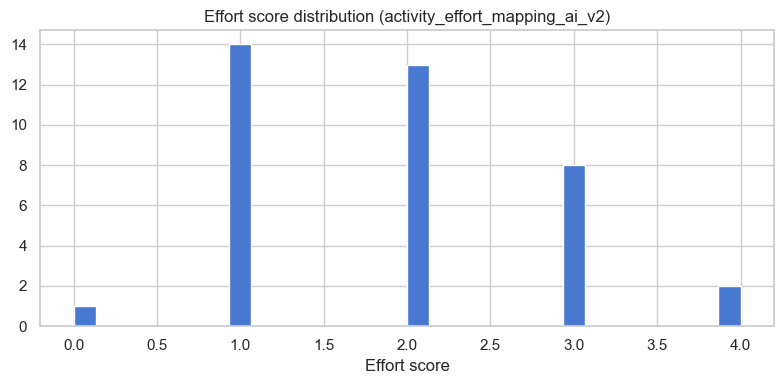

In [13]:
effort_scores = con.execute("""
    SELECT ai_effort_rank
    FROM activity_effort_mapping_ai_v2
    WHERE ai_effort_rank IS NOT NULL
""").fetchdf()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(effort_scores['ai_effort_rank'], bins=30, edgecolor='white')
ax.set_title('Effort score distribution (activity_effort_mapping_ai_v2)')
ax.set_xlabel('Effort score')
plt.tight_layout()
plt.show()

## 5. Recency Features (`dev_recency_features_v2`)

In [ ]:
display(con.execute("DESCRIBE dev_recency_features_v2").fetchdf())

,column_name,column_type,null,key,default,extra
0,developer_id,VARCHAR,YES,None,None,None
1,activity_count_0_30d,BIGINT,YES,None,None,None
2,activity_count_30_90d,BIGINT,YES,None,None,None
3,activity_count_90_180d,BIGINT,YES,None,None,None
4,has_activity_0_30d,INTEGER,YES,None,None,None
5,has_activity_30_90d,INTEGER,YES,None,None,None
6,has_activity_90_180d,INTEGER,YES,None,None,None
7,log_activity_count_0_30d,DOUBLE,YES,None,None,None
8,log_activity_count_30_90d,DOUBLE,YES,None,None,None
9,log_activity_count_90_180d,DOUBLE,YES,None,None,None


In [14]:
recency_cols = ['days_since_last_activity', 'days_since_first_activity', 'active_days_total']
existing = [r[0] for r in con.execute("DESCRIBE dev_recency_features_v2").fetchall()]
recency_cols = [c for c in recency_cols if c in existing]

if recency_cols:
    stats = con.execute(f"""
        SELECT {', '.join([f'MIN({c}) AS {c}_min, MAX({c}) AS {c}_max, AVG({c}) AS {c}_mean, MEDIAN({c}) AS {c}_median' for c in recency_cols])}
        FROM dev_recency_features_v2
    """).fetchdf()
    display(stats)

In [15]:
flag_cols = ['has_activity_0_30d', 'has_activity_30_90d', 'has_activity_90_180d', 'newly_inactive_0_30d']
existing = [r[0] for r in con.execute("DESCRIBE dev_recency_features_v2").fetchall()]
flag_cols = [c for c in flag_cols if c in existing]

if flag_cols:
    flag_df = con.execute(f"""
        SELECT {', '.join([f'AVG(CAST({c} AS DOUBLE)) AS pct_{c}' for c in flag_cols])}
        FROM dev_recency_features_v2
    """).fetchdf()
    display(flag_df)

,pct_has_activity_0_30d,pct_has_activity_30_90d,pct_has_activity_90_180d,pct_newly_inactive_0_30d
0,0.0446,0.0453,0.0555,0.0380


## 7. Lifetime Features (`dev_features_lifetime_v2`)

In [16]:
display(con.execute("DESCRIBE dev_features_lifetime_v2").fetchdf())

,column_name,column_type,null,key,default,extra
0,developer_id,VARCHAR,YES,None,None,None
1,lifetime_activity_count,BIGINT,YES,None,None,None
2,lifetime_activity_score_sum,DOUBLE,YES,None,None,None
3,lifetime_activity_score_avg,DOUBLE,YES,None,None,None
4,lifetime_unique_activity_days,BIGINT,YES,None,None,None
5,lifetime_unique_activity_types,BIGINT,YES,None,None,None
6,lifetime_unique_modalities,BIGINT,YES,None,None,None
7,lifetime_active_weeks,BIGINT,YES,None,None,None
8,lifetime_first_activity_date,DATE,YES,None,None,None
9,lifetime_last_activity_date,DATE,YES,None,None,None


In [17]:
cols = [r[0] for r in con.execute("DESCRIBE dev_features_lifetime_v2").fetchall()]
total = con.execute("SELECT COUNT(*) FROM dev_features_lifetime_v2").fetchone()[0]
null_rates = {}
for col in cols:
    n_null = con.execute(f"SELECT COUNT(*) FROM dev_features_lifetime_v2 WHERE {col} IS NULL").fetchone()[0]
    null_rates[col] = round(100 * n_null / total, 2)

null_df = pd.DataFrame.from_dict(null_rates, orient='index', columns=['null_pct']).sort_values('null_pct', ascending=False)
display(null_df[null_df['null_pct'] > 0])

,null_pct
high_effort_share_lifetime,18.3500
lifetime_first_activity_date,18.3500
effort_per_activity_lifetime,18.3500
lifetime_last_activity_date,18.3500
activity_per_active_week_lifetime,18.3500
build_share_lifetime,18.3500
score_effort_misalignment_share_lifetime,18.3500


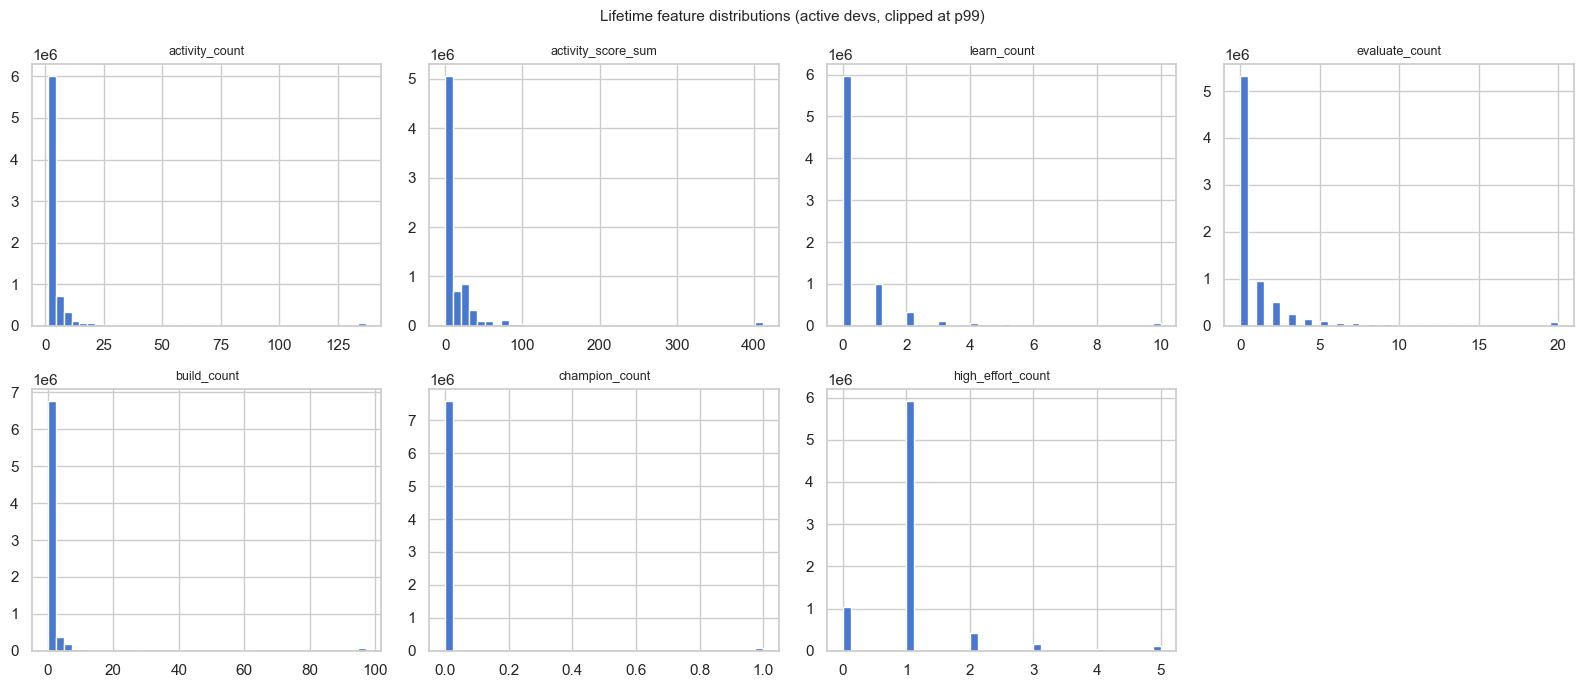

In [18]:
numeric_cols = [
    'lifetime_activity_count', 'lifetime_activity_score_sum',
    'lifetime_learn_count', 'lifetime_evaluate_count',
    'lifetime_build_count', 'lifetime_champion_count',
    'lifetime_high_effort_count'
]
existing = [r[0] for r in con.execute("DESCRIBE dev_features_lifetime_v2").fetchall()]
numeric_cols = [c for c in numeric_cols if c in existing]

df = con.execute(f"SELECT {', '.join(numeric_cols)} FROM dev_features_lifetime_v2 WHERE lifetime_activity_count > 0").fetchdf()

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].clip(upper=df[col].quantile(0.99)), bins=40, edgecolor='white')
    axes[i].set_title(col.replace('lifetime_', ''), fontsize=9)
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Lifetime feature distributions (active devs, clipped at p99)', fontsize=11)
plt.tight_layout()
plt.show()

## 8. Windowed Features (30 / 30-90 / 90-180 days)

In [19]:
windows = {
    '0-30d':   'dev_features_0_30d_v2',
    '30-90d':  'dev_features_30_90d_v2',
    '90-180d': 'dev_features_90_180d_v2',
}
present_tables = [r[0] for r in con.execute("SHOW TABLES").fetchall()]

for label, tbl in windows.items():
    if tbl not in present_tables:
        print(f"{tbl} not found, skipping.")
        continue
    n = con.execute(f"SELECT COUNT(*) FROM {tbl}").fetchone()[0]
    n_active = con.execute(f"SELECT COUNT(*) FROM {tbl} WHERE activity_count > 0").fetchone()[0]
    print(f"{label} ({tbl}): {n:,} rows, {n_active:,} active ({100*n_active/n:.1f}%)")

0-30d (dev_features_0_30d_v2): 9,381,508 rows, 418,049 active (4.5%)
30-90d (dev_features_30_90d_v2): 9,381,508 rows, 425,272 active (4.5%)
90-180d (dev_features_90_180d_v2): 9,381,508 rows, 520,752 active (5.6%)


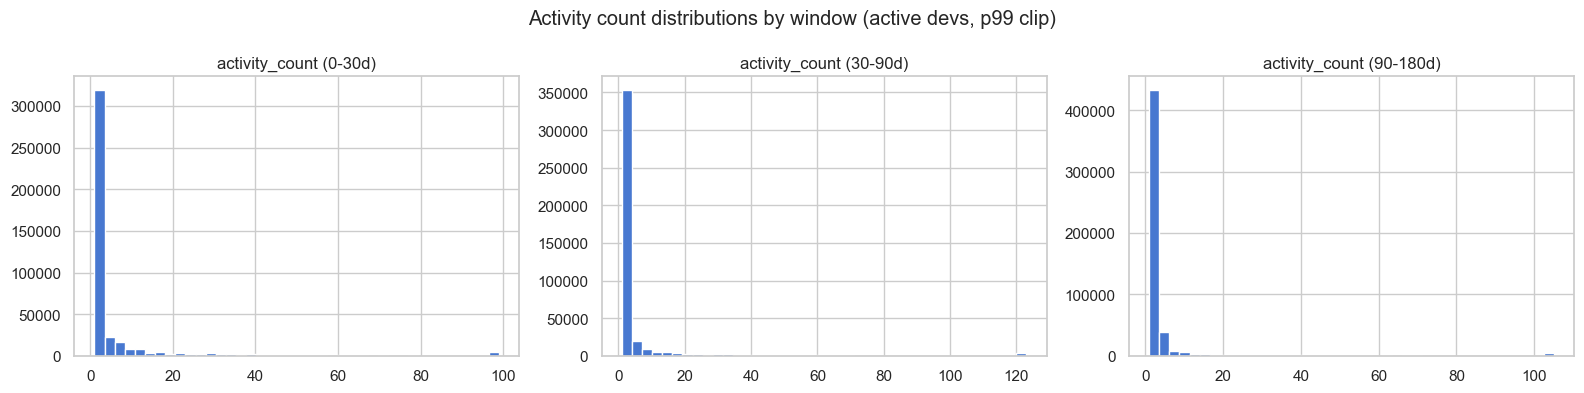

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (label, tbl) in zip(axes, windows.items()):
    if tbl not in present_tables:
        ax.set_visible(False)
        continue
    vals = con.execute(f"SELECT activity_count FROM {tbl} WHERE activity_count > 0").fetchdf()
    ax.hist(vals['activity_count'].clip(upper=vals['activity_count'].quantile(0.99)), bins=40, edgecolor='white')
    ax.set_title(f'activity_count ({label})')
plt.suptitle('Activity count distributions by window (active devs, p99 clip)')
plt.tight_layout()
plt.show()

## 9. Effort Level (`dev_effort_level_v2`)

,column_name,column_type,null,key,default,extra
0,developer_id,VARCHAR,YES,None,None,None
1,lifetime_activity_count,BIGINT,YES,None,None,None
2,lifetime_activity_score_sum,DOUBLE,YES,None,None,None
3,lifetime_unique_activity_types,BIGINT,YES,None,None,None
4,lifetime_unique_modalities,BIGINT,YES,None,None,None
5,lifetime_high_effort_count,HUGEINT,YES,None,None,None
6,lifetime_avg_effort_rank,DOUBLE,YES,None,None,None
7,lifetime_max_effort_rank,DOUBLE,YES,None,None,None
8,lifetime_total_confidence_weighted_effort,DOUBLE,YES,None,None,None
9,lifetime_avg_score_effort_gap,DOUBLE,YES,None,None,None


,developer_effort_level,n
0,low effort,3590938
1,medium effort,2152014
2,no activity,1721230
3,high effort,1151291
4,very high effort,766035


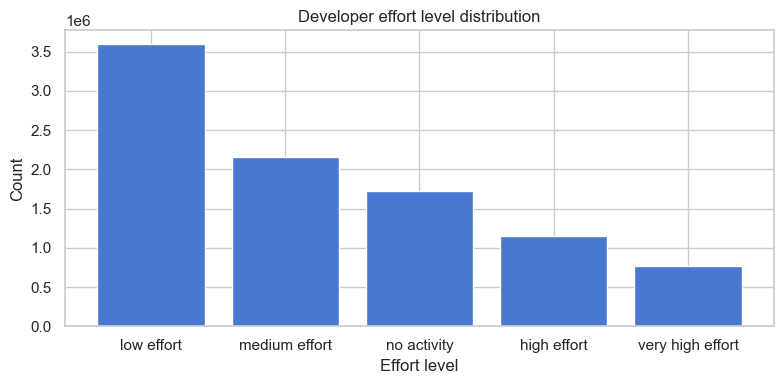

In [22]:
display(con.execute("DESCRIBE dev_effort_level_v2").fetchdf())

el = con.execute("""
    SELECT developer_effort_level, COUNT(*) AS n
    FROM dev_effort_level_v2
    GROUP BY developer_effort_level ORDER BY n DESC
""").fetchdf()
display(el)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(el['developer_effort_level'].astype(str), el['n'])
ax.set_title('Developer effort level distribution')
ax.set_xlabel('Effort level')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## 10. Persona (`dev_persona_v2`)

In [23]:
display(con.execute("DESCRIBE dev_persona_v2").fetchdf())

,column_name,column_type,null,key,default,extra
0,developer_id,VARCHAR,YES,None,None,None
1,cuda_score,DOUBLE,YES,None,None,None
2,genai_score,DOUBLE,YES,None,None,None
3,robotics_score,DOUBLE,YES,None,None,None
4,simulation_score,DOUBLE,YES,None,None,None
5,learning_community_score,DOUBLE,YES,None,None,None
6,other_persona_score,DOUBLE,YES,None,None,None
7,specific_persona_score,DOUBLE,YES,None,None,None
8,total_persona_score,DOUBLE,YES,None,None,None
9,cuda_share,DOUBLE,YES,None,None,None


,persona,n
0,CUDA,3519981
1,GenAI,2314671
2,Unknown,1869569
3,Robotics,590804
4,Simulation,570051
5,Learning_Community,516432


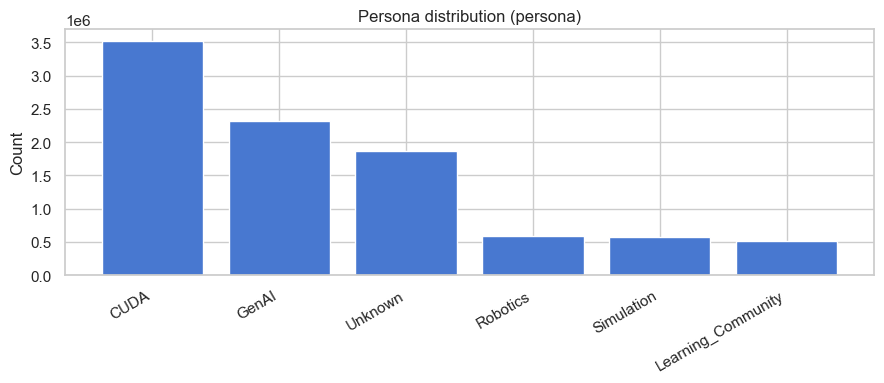

In [24]:
persona_col_candidates = ['top_persona', 'primary_persona', 'persona']
existing_cols = [r[0] for r in con.execute("DESCRIBE dev_persona_v2").fetchall()]
persona_col = next((c for c in persona_col_candidates if c in existing_cols), None)

if persona_col:
    p = con.execute(f"""
        SELECT {persona_col}, COUNT(*) AS n
        FROM dev_persona_v2
        GROUP BY {persona_col} ORDER BY n DESC
    """).fetchdf()
    display(p)

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(p[persona_col].astype(str), p['n'])
    ax.set_title(f'Persona distribution ({persona_col})')
    ax.set_ylabel('Count')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No top_persona/primary_persona column found — check DESCRIBE output above.")

In [25]:
score_cols = [c for c in existing_cols if 'score' in c or 'persona' in c]
score_cols = [c for c in score_cols if c != persona_col]

if score_cols:
    df = con.execute(f"SELECT {', '.join(score_cols)} FROM dev_persona_v2").fetchdf()
    display(df[score_cols].describe())

,cuda_score,genai_score,robotics_score,simulation_score,learning_community_score,other_persona_score,specific_persona_score,total_persona_score,persona_entropy,persona_confidence,mixed_persona_flag
count,9381508.0000,9381508.0000,9381508.0000,9381508.0000,9381508.0000,9381508.0000,9381508.0000,9381508.0000,9381508.0000,9381508.0000,9381508.0000
mean,9.3828,4.3639,6.4186,0.9745,3.8651,7.3845,25.0049,32.3894,0.2354,0.6094,0.2449
std,1226.5091,1011.2361,181.0110,213.9540,36.4043,1209.9766,2559.1960,3718.4097,0.2654,0.3689,0.4300
min,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000
25%,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,2.0000,-0.0000,0.4000,0.0000
50%,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,3.0000,6.0000,0.0957,0.6494,0.0000
75%,6.0000,1.0000,0.0000,1.0000,1.0000,2.0000,14.0000,20.0000,0.4307,1.0000,0.0000
max,3453967.0000,2825576.0000,403227.0000,653185.0000,88580.0000,3123109.0000,7424535.0000,10547644.0000,1.0000,1.0000,1.0000


## 11. Journey State (`dev_journey_state_v2`)

In [26]:
display(con.execute("DESCRIBE dev_journey_state_v2").fetchdf())

,column_name,column_type,null,key,default,extra
0,developer_id,VARCHAR,YES,None,None,None
1,behavior_journey_stage_30d,VARCHAR,YES,None,None,None
2,current_journey_state_30d,VARCHAR,YES,None,None,None
3,behavior_journey_rank_30d,INTEGER,YES,None,None,None
4,current_journey_rank_30d,INTEGER,YES,None,None,None
5,activity_volume_band,VARCHAR,YES,None,None,None
6,intent_signal,VARCHAR,YES,None,None,None
7,trend_signal,VARCHAR,YES,None,None,None
8,recent_activity_trend_ratio,DOUBLE,YES,None,None,None


In [27]:
js_col_candidates = ['journey_state', 'current_state', 'state']
existing_cols = [r[0] for r in con.execute("DESCRIBE dev_journey_state_v2").fetchall()]
js_col = next((c for c in js_col_candidates if c in existing_cols), None)

if js_col:
    js = con.execute(f"""
        SELECT {js_col}, COUNT(*) AS n
        FROM dev_journey_state_v2
        GROUP BY {js_col} ORDER BY n DESC
    """).fetchdf()
    display(js)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(js[js_col].astype(str), js['n'])
    ax.set_title('Journey state distribution')
    ax.set_xlabel('Count')
    plt.tight_layout()
    plt.show()
else:
    print("No journey_state column found — check DESCRIBE output above.")

No journey_state column found — check DESCRIBE output above.


## 12. Dormancy (`dev_dormancy_status_v2`)

In [28]:
display(con.execute("DESCRIBE dev_dormancy_status_v2").fetchdf())

,column_name,column_type,null,key,default,extra
0,developer_id,VARCHAR,YES,None,None,None
1,is_activated,INTEGER,YES,None,None,None
2,lifetime_activity_count_for_activation,BIGINT,YES,None,None,None
3,lifetime_meaningful_weeks,HUGEINT,YES,None,None,None
4,first_meaningful_week_start,TIMESTAMP,YES,None,None,None
5,last_meaningful_week_start,TIMESTAMP,YES,None,None,None
6,lifetime_first_activity_date,DATE,YES,None,None,None
7,lifetime_last_activity_date,DATE,YES,None,None,None
8,days_since_last_activity,BIGINT,YES,None,None,None
9,days_since_last_meaningful_week,BIGINT,YES,None,None,None


,dormancy_status,n
0,Dormant,5304852
1,Unactivated,1721230
2,At_Risk,1580877
3,Active,418049
4,Cooling,356500


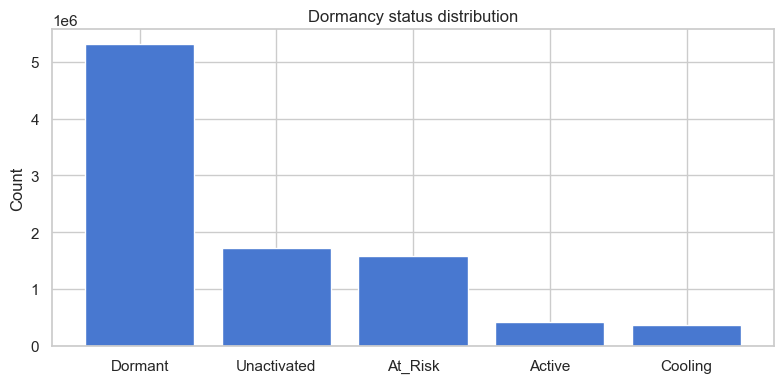

In [29]:
dorm_col_candidates = ['dormancy_status', 'dormant', 'is_dormant', 'status']
existing_cols = [r[0] for r in con.execute("DESCRIBE dev_dormancy_status_v2").fetchall()]
dorm_col = next((c for c in dorm_col_candidates if c in existing_cols), None)

if dorm_col:
    d = con.execute(f"""
        SELECT {dorm_col}, COUNT(*) AS n
        FROM dev_dormancy_status_v2
        GROUP BY {dorm_col} ORDER BY n DESC
    """).fetchdf()
    display(d)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(d[dorm_col].astype(str), d['n'])
    ax.set_title('Dormancy status distribution')
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.show()
else:
    print("No dormancy_status/dormant column found — check DESCRIBE output above.")

## 13. Activation (`dev_activation_v2`)

In [30]:
display(con.execute("DESCRIBE dev_activation_v2").fetchdf())

,column_name,column_type,null,key,default,extra
0,developer_id,VARCHAR,YES,None,None,None
1,is_activated,INTEGER,YES,None,None,None
2,lifetime_activity_count_for_activation,BIGINT,YES,None,None,None
3,lifetime_meaningful_weeks,HUGEINT,YES,None,None,None
4,first_meaningful_week_start,TIMESTAMP,YES,None,None,None
5,last_meaningful_week_start,TIMESTAMP,YES,None,None,None
6,lifetime_first_activity_date,DATE,YES,None,None,None
7,lifetime_last_activity_date,DATE,YES,None,None,None


In [31]:
display(con.execute("""
    SELECT
        COUNT(*) AS total,
        COUNT(CASE WHEN is_activated THEN 1 END) AS activated,
        ROUND(100.0 * COUNT(CASE WHEN is_activated THEN 1 END) / COUNT(*), 2) AS activation_rate_pct
    FROM dev_activation_v2
""").fetchdf())

,total,activated,activation_rate_pct
0,9381508,7660278,81.6500


In [32]:
act_cols = [r[0] for r in con.execute("DESCRIBE dev_activation_v2").fetchall()]
days_col = next((c for c in act_cols if 'days' in c), None)

if days_col:
    vals = con.execute(f"""
        SELECT {days_col} FROM dev_activation_v2
        WHERE {days_col} IS NOT NULL AND {days_col} >= 0
    """).fetchdf()
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(vals[days_col].clip(upper=vals[days_col].quantile(0.99)), bins=50, edgecolor='white')
    ax.set_title(f'{days_col} distribution (p99 clip)')
    ax.set_xlabel('Days')
    plt.tight_layout()
    plt.show()

## 14. Final Profile (`dev_profile_final_v4`)

In [33]:
display(con.execute("DESCRIBE dev_profile_final_v4").fetchdf())

,column_name,column_type,null,key,default,extra
0,developer_id,VARCHAR,YES,None,None,None
1,persona,VARCHAR,YES,None,None,None
2,persona_confidence,DOUBLE,YES,None,None,None
3,persona_confidence_tier,VARCHAR,YES,None,None,None
4,persona_entropy,DOUBLE,YES,None,None,None
...,...,...,...,...,...,...
140,organization_english_name,VARCHAR,YES,None,None,None
141,normalized_account_name,VARCHAR,YES,None,None,None
142,wwfo_category,VARCHAR,YES,None,None,None
143,wwfo_target_list,VARCHAR,YES,None,None,None


In [34]:
cols = [r[0] for r in con.execute("DESCRIBE dev_profile_final_v4").fetchall()]
total = con.execute("SELECT COUNT(*) FROM dev_profile_final_v4").fetchone()[0]
null_rates = {}
for col in cols:
    n_null = con.execute(f"SELECT COUNT(*) FROM dev_profile_final_v4 WHERE {col} IS NULL").fetchone()[0]
    null_rates[col] = round(100 * n_null / total, 2)

null_df = pd.DataFrame.from_dict(null_rates, orient='index', columns=['null_pct']).sort_values('null_pct', ascending=False)
print(f"Total rows: {total:,}")
display(null_df[null_df['null_pct'] > 0])

Total rows: 9,381,508


,null_pct
build_velocity_0_30_vs_30_90,99.0300
high_effort_share_0_30d,95.5400
build_share_0_30d,95.5400
confidence_weighted_effort_per_activity_0_30d,95.5400
score_effort_misalignment_share_0_30d,95.5400
days_since_last_activity_0_30d,95.5400
activity_per_active_day_0_30d,95.5400
activity_velocity_0_30_vs_30_90,95.4700
last_meaningful_week_start,56.3300
days_since_last_meaningful_week,56.3300


In [35]:
display(con.execute("SELECT * FROM dev_profile_final_v4 LIMIT 5").fetchdf())

,developer_id,persona,persona_confidence,persona_confidence_tier,persona_entropy,mixed_persona_flag,cuda_share,genai_share,robotics_share,simulation_share,learning_community_share,developer_effort_score,developer_effort_level,developer_effort_rank,effort_recency_weight,behavior_journey_stage_30d,behavior_journey_rank_30d,current_journey_state_30d,current_journey_rank_30d,is_activated,lifetime_meaningful_weeks,last_meaningful_week_start,days_since_last_meaningful_week,days_since_last_activity,dormancy_status,dormant_flag,at_risk_flag,cooling_flag,final_lifecycle_status,activity_count_0_30d,activity_count_30_90d,activity_count_90_180d,has_activity_0_30d,has_activity_30_90d,has_activity_90_180d,log_activity_count_0_30d,log_activity_count_30_90d,log_activity_count_90_180d,build_count_0_30d,build_count_30_90d,build_count_90_180d,log_build_count_0_30d,log_build_count_30_90d,log_build_count_90_180d,high_effort_count_0_30d,high_effort_count_30_90d,high_effort_count_90_180d,unique_activity_days_0_30d,unique_activity_types_0_30d,unique_modalities_0_30d,activity_per_active_day_0_30d,build_share_0_30d,high_effort_share_0_30d,avg_effort_rank_0_30d,avg_effort_rank_30_90d,avg_effort_rank_90_180d,total_confidence_weighted_effort_0_30d,total_confidence_weighted_effort_30_90d,total_confidence_weighted_effort_90_180d,confidence_weighted_effort_per_activity_0_30d,avg_score_effort_gap_0_30d,score_effort_misalignment_count_0_30d,score_effort_misalignment_share_0_30d,low_medium_confidence_effort_count_0_30d,effort_x_activity_score_sum_0_30d,days_since_last_activity_0_30d,is_missing_last_activity_0_30d,activity_velocity_0_30_vs_30_90,build_velocity_0_30_vs_30_90,weighted_recent_activity,weighted_recent_build,weighted_recent_confidence_effort,active_non_builder_0_30d,newly_inactive_0_30d,low_volume_builder_0_30d,has_high_effort_0_30d,recent_build_flag,recent_champion_flag,lifetime_activity_count,lifetime_activity_score_sum,lifetime_activity_score_avg,lifetime_unique_activity_days,lifetime_unique_activity_types,lifetime_unique_modalities,lifetime_active_weeks,lifetime_first_activity_date,lifetime_last_activity_date,lifetime_discover_count,lifetime_learn_count,lifetime_evaluate_count,lifetime_build_count,lifetime_champion_count,lifetime_high_effort_count,lifetime_avg_effort_rank,lifetime_max_effort_rank,lifetime_total_confidence_weighted_effort,lifetime_avg_score_effort_gap,lifetime_score_effort_misalignment_count,lifetime_low_medium_confidence_effort_count,lifetime_effort_x_activity_score_sum,lifetime_dli_training_count,lifetime_webinar_count,lifetime_forum_count,lifetime_bug_count,lifetime_hackathon_count,lifetime_api_count,lifetime_devzone_download_count,lifetime_ngc_download_count,user_type,max_stage_reached,has_lifetime_activity,log_lifetime_activity_count,log_lifetime_activity_score_sum,log_lifetime_build_count,log_lifetime_high_effort_count,effort_per_activity_lifetime,score_effort_misalignment_share_lifetime,log_lifetime_total_confidence_weighted_effort,log_lifetime_effort_x_activity_score_sum,clipped_lifetime_activity_count_p99,clipped_lifetime_build_count_p99,clipped_lifetime_activity_score_sum_p99,clipped_lifetime_total_confidence_weighted_effort_p99,clipped_lifetime_effort_x_activity_score_sum_p99,log_clipped_lifetime_activity_count_p99,log_clipped_lifetime_activity_score_sum_p99,log_clipped_lifetime_total_confidence_weighted_effort_p99,log_clipped_lifetime_effort_x_activity_score_sum_p99,activity_per_active_week_lifetime,build_share_lifetime,high_effort_share_lifetime,contact_created_date,contact_first_activity_date,contact_last_activity_date,account_id,account_type,country,region,industry_segment_vertical,program_application_source,organization_english_name,normalized_account_name,wwfo_category,wwfo_target_list,missing_contact_metadata_flag
0,3519552,CUDA,0.9091,High,0.1893,0,0.9091,0.0909,0.0000,0.0000,0.0000,0.4842,medium effort,2,0.2500,Historically_Active,1,Dormant_Historically_Active,1,1,2.0000,2021-12-06,1619,1554,Dormant,1,0,0,Dorma

In [36]:
all_cols = [r[0] for r in con.execute("DESCRIBE dev_profile_final_v4").fetchall()]
dtypes = {r[0]: r[1] for r in con.execute("DESCRIBE dev_profile_final_v4").fetchall()}
numeric_cols = [c for c, t in dtypes.items() if any(x in t.upper() for x in ['INT', 'DOUBLE', 'FLOAT', 'DECIMAL', 'BIGINT'])]

if numeric_cols:
    df = con.execute(f"SELECT {', '.join(numeric_cols)} FROM dev_profile_final_v4").fetchdf()
    display(df.describe())

100% ▕██████████████████████████████████████▏ (00:00:02.31 elapsed)     
 99% ▕█████████████████████████████████████▌▏ (<1 second remaining)     

,persona_confidence,persona_entropy,mixed_persona_flag,cuda_share,genai_share,robotics_share,simulation_share,learning_community_share,developer_effort_score,developer_effort_rank,effort_recency_weight,behavior_journey_rank_30d,current_journey_rank_30d,is_activated,lifetime_meaningful_weeks,days_since_last_meaningful_week,days_since_last_activity,dormant_flag,at_risk_flag,cooling_flag,activity_count_0_30d,activity_count_30_90d,activity_count_90_180d,has_activity_0_30d,has_activity_30_90d,has_activity_90_180d,log_activity_count_0_30d,log_activity_count_30_90d,log_activity_count_90_180d,build_count_0_30d,build_count_30_90d,build_count_90_180d,log_build_count_0_30d,log_build_count_30_90d,log_build_count_90_180d,high_effort_count_0_30d,high_effort_count_30_90d,high_effort_count_90_180d,unique_activity_days_0_30d,unique_activity_types_0_30d,unique_modalities_0_30d,activity_per_active_day_0_30d,build_share_0_30d,high_effort_share_0_30d,avg_effort_rank_0_30d,avg_effort_rank_30_90d,avg_effort_rank_90_180d,total_confidence_weighted_effort_0_30d,total_confidence_weighted_effort_30_90d,total_confidence_weighted_effort_90_180d,confidence_weighted_effort_per_activity_0_30d,avg_score_effort_gap_0_30d,score_effort_misalignment_count_0_30d,score_effort_misalignment_share_0_30d,low_medium_confidence_effort_count_0_30d,effort_x_activity_score_sum_0_30d,days_since_last_activity_0_30d,is_missing_last_activity_0_30d,activity_velocity_0_30_vs_30_90,build_velocity_0_30_vs_30_90,weighted_recent_activity,weighted_recent_build,weighted_recent_confidence_effort,active_non_builder_0_30d,newly_inactive_0_30d,low_volume_builder_0_30d,has_high_effort_0_30d,recent_build_flag,recent_champion_flag,lifetime_activity_count,lifetime_activity_score_sum,lifetime_activity_score_avg,lifetime_unique_activity_days,lifetime_unique_activity_types,lifetime_unique_modalities,lifetime_active_weeks,lifetime_discover_count,lifetime_learn_count,lifetime_evaluate_count,lifetime_build_count,lifetime_champion_count,lifetime_high_effort_count,lifetime_avg_effort_rank,lifetime_max_effort_rank,lifetime_total_confidence_weighted_effort,lifetime_avg_score_effort_gap,lifetime_score_effort_misalignment_count,lifetime_low_medium_confidence_effort_count,lifetime_effort_x_activity_score_sum,lifetime_dli_training_count,lifetime_webinar_count,lifetime_forum_count,lifetime_bug_count,lifetime_hackathon_count,lifetime_api_count,lifetime_devzone_download_count,lifetime_ngc_download_count,has_lifetime_activity,log_lifetime_activity_count,log_lifetime_activity_score_sum,log_lifetime_build_count,log_lifetime_high_effort_count,effort_per_activity_lifetime,score_effort_misalignment_share_lifetime,log_lifetime_total_confidence_weighted_effort,log_lifetime_effort_x_activity_score_sum,clipped_lifetime_activity_count_p99,clipped_lifetime_build_count_p99,clipped_lifetime_activity_score_sum_p99,clipped_lifetime_total_confidence_weighted_effort_p99,clipped_lifetime_effort_x_activity_score_sum_p99,log_clipped_lifetime_activity_count_p99,log_clipped_lifetime_activity_score_sum_p99,log_clipped_lifetime_total_confidence_weighted_effort_p99,log_clipped_lifetime_effort_x_activity_score_sum_p99,activity_per_active_week_lifetime,build_share_lifetime,high_effort_share_lifetime,missing_contact_metadata_flag
count,9381508.0000,9381508.0000,9381508.0000,9381508.0000,9381508.0000,9381508.0000,9381508.0000,9381508.0000,9381508.0000,9381508.0000,9381508.0000,9381508.0000,9381508.0000,9381508.0000,9381508.0000,4097286.0000,7660278.0000,9381508.0000,9381508.0000,9381508.0000,9381508.0000,9381508.0000,9381508.0000,9381508.0000,9381508.0000,9381508.0000,9381508.0000,9381508.0000,9381508.0000,9381508.0000,9381508.0000,9381508.0000,9381508.0000,9381508.0000,9381508.0000,9381508.0000,9381508.0000,9381508.0000,9381508.0000,9381508.0000,9381508.0000,418049.0000,418049.0000,418049.0000,9381508.0000,9381508.0000,9381508.0000,9381508.0000,9381508.0000,9381508.0000,418049.0000,9381508.0000,9381508.0000,418049.0000,9381508.0000,9381508

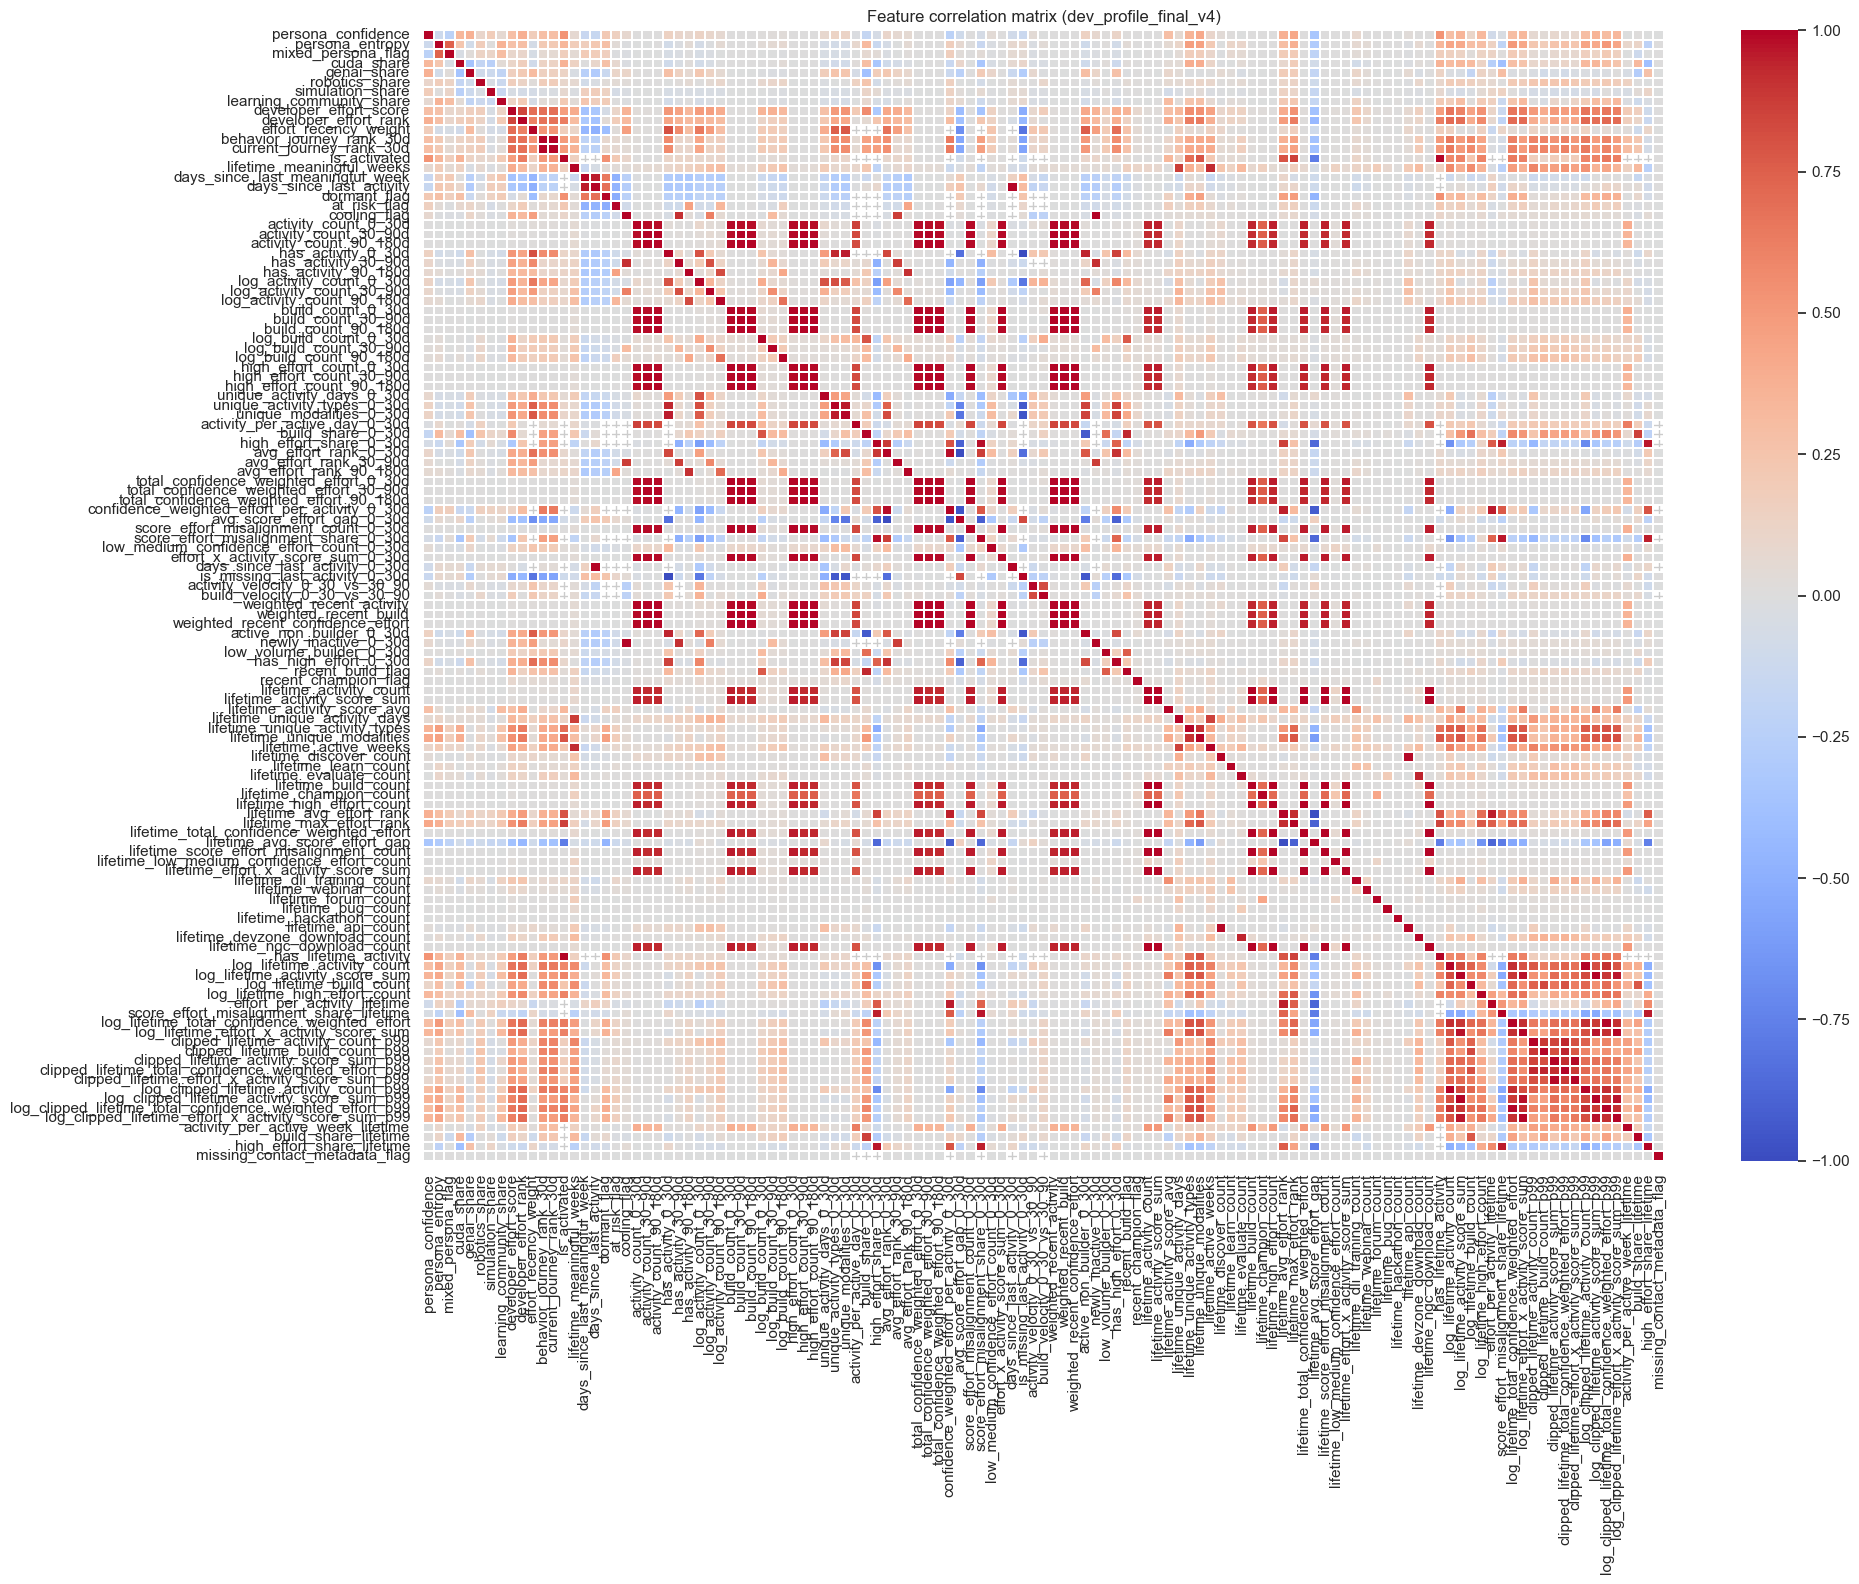

In [37]:
if numeric_cols and len(numeric_cols) > 1:
    corr = df[numeric_cols].corr()
    fig, ax = plt.subplots(figsize=(min(20, len(numeric_cols)), min(16, len(numeric_cols))))
    sns.heatmap(corr, ax=ax, cmap='coolwarm', center=0, linewidths=0.3,
                xticklabels=True, yticklabels=True, annot=len(numeric_cols) <= 15)
    ax.set_title('Feature correlation matrix (dev_profile_final_v4)')
    plt.tight_layout()
    plt.show()

## 15. Cross-Table Sanity Checks

In [38]:
universe_n = con.execute("SELECT COUNT(*) FROM developer_universe_v2").fetchone()[0]

coverage_tables = [
    'dev_recency_features_v2',
    'dev_features_lifetime_v2',
    'dev_effort_level_v2',
    'dev_persona_v2',
    'dev_journey_state_v2',
    'dev_dormancy_status_v2',
    'dev_activation_v2',
    'dev_profile_final_v4',
]

present_tables = [r[0] for r in con.execute("SHOW TABLES").fetchall()]
rows = []
for tbl in coverage_tables:
    if tbl not in present_tables:
        rows.append({'table': tbl, 'row_count': None, 'pct_of_universe': None})
        continue
    n = con.execute(f"SELECT COUNT(*) FROM {tbl}").fetchone()[0]
    rows.append({'table': tbl, 'row_count': n, 'pct_of_universe': round(100 * n / universe_n, 1)})

display(pd.DataFrame(rows))

,table,row_count,pct_of_universe
0,dev_recency_features_v2,9381508,100.0000
1,dev_features_lifetime_v2,9381508,100.0000
2,dev_effort_level_v2,9381508,100.0000
3,dev_persona_v2,9381508,100.0000
4,dev_journey_state_v2,9381508,100.0000
5,dev_dormancy_status_v2,9381508,100.0000
6,dev_activation_v2,9381508,100.0000
7,dev_profile_final_v4,9381508,100.0000


In [39]:
display(con.execute("""
    SELECT
        COUNT(*) AS profile_rows,
        COUNT(DISTINCT p.developer_id) AS unique_developers,
        COUNT(CASE WHEN a.developer_id IS NULL THEN 1 END) AS missing_in_activation,
        COUNT(CASE WHEN js.developer_id IS NULL THEN 1 END) AS missing_in_journey_state
    FROM dev_profile_final_v4 p
    LEFT JOIN dev_activation_v2 a ON p.developer_id = a.developer_id
    LEFT JOIN dev_journey_state_v2 js ON p.developer_id = js.developer_id
""").fetchdf())

,profile_rows,unique_developers,missing_in_activation,missing_in_journey_state
0,9381508,9381508,0,0


## 16. Teardown

In [40]:
con.close()
print("Connection closed.")

Connection closed.
